# Ultramarathon Performance Visualizations — Part C
**Group 17 — Luiz Samelo, Maximilian Staudacher, Rayudu Muralikrishna**
*Information Visualization (VU 2.0), TU Wien, 2026*

- **Viz 5**: Age vs. speed scatter by gender
- **Viz 6**: Athlete career arc

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/TWO_CENTURIES_OF_UM_RACES.csv')
print('Shape:', df.shape)
df.head()

Shape: (7461195, 13)


,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
0,2018,06.01.2018,Selva Costera (CHI),50km,22,4:51:39 h,Tnfrc,CHI,1978.0,M,M35,10.286,0
1,2018,06.01.2018,Selva Costera (CHI),50km,22,5:15:45 h,Roberto Echeverría,CHI,1981.0,M,M35,9.501,1
2,2018,06.01.2018,Selva Costera (CHI),50km,22,5:16:44 h,Puro Trail Osorno,CHI,1987.0,M,M23,9.472,2
3,2018,06.01.2018,Selva Costera (CHI),50km,22,5:34:13 h,Columbia,ARG,1976.0,M,M40,8.976,3
4,2018,06.01.2018,Selva Costera (CHI),50km,22,5:54:14 h,Baguales Trail,CHI,1992.0,M,M23,8.469,4


In [2]:
df.columns = [
    'year', 'event_dates', 'race_name', 'race_length', 'num_finishers',
    'athlete_performance', 'athlete_club', 'athlete_country',
    'athlete_year_of_birth', 'athlete_gender', 'athlete_age_category',
    'athlete_avg_speed', 'athlete_id'
]
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['athlete_avg_speed'] = pd.to_numeric(df['athlete_avg_speed'], errors='coerce')
df['athlete_year_of_birth'] = pd.to_numeric(df['athlete_year_of_birth'], errors='coerce')
df['athlete_age'] = df['year'] - df['athlete_year_of_birth']

df_clean = df[
    (df['athlete_avg_speed'] > 0) & (df['athlete_avg_speed'] < 30) &
    (df['athlete_age'] >= 18) & (df['athlete_age'] <= 80) &
    (df['athlete_gender'].isin(['M', 'F'])) &
    (df['year'] >= 1970) & (df['year'] <= 2022)
].copy()
df_clean['Gender'] = df_clean['athlete_gender'].map({'M': 'Male', 'F': 'Female'})
df_clean['athlete_age'] = df_clean['athlete_age'].astype(int)
print('Cleaned shape:', df_clean.shape)

Cleaned shape: (6299362, 15)


## Viz 5 — Age vs Speed by Gender

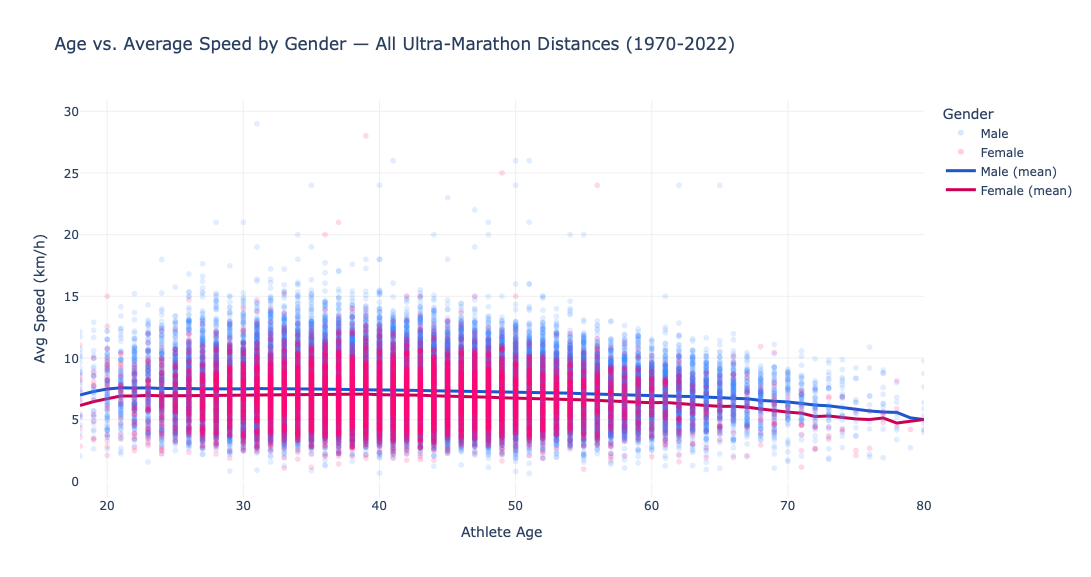

Saved viz5 PNG


In [3]:
df_scatter = df_clean.sample(n=min(50000, len(df_clean)), random_state=42).copy()
age_trend = (
    df_clean.groupby(['athlete_age', 'athlete_gender'])
    .agg(mean_speed=('athlete_avg_speed', 'mean'), count=('athlete_avg_speed', 'count'))
    .reset_index()
)
age_trend = age_trend[age_trend['count'] >= 50]
age_trend['Gender'] = age_trend['athlete_gender'].map({'M': 'Male', 'F': 'Female'})

fig5 = px.scatter(
    df_scatter,
    x='athlete_age', y='athlete_avg_speed', color='Gender',
    color_discrete_map={'Male': '#3A86FF', 'Female': '#FF006E'},
    opacity=0.15,
    labels={'athlete_age': 'Athlete Age', 'athlete_avg_speed': 'Avg Speed (km/h)'},
    title='Age vs. Average Speed by Gender — All Ultra-Marathon Distances (1970-2022)'
)
for gender, color in [('Male', '#1a56cc'), ('Female', '#cc0052')]:
    trend = age_trend[age_trend['Gender'] == gender].sort_values('athlete_age')
    fig5.add_trace(go.Scatter(
        x=trend['athlete_age'], y=trend['mean_speed'],
        mode='lines', name=f'{gender} (mean)',
        line=dict(color=color, width=3)
    ))
fig5.update_layout(
    height=560, plot_bgcolor='white', paper_bgcolor='white',
    title_font_size=17,
    xaxis=dict(title='Athlete Age', range=[18, 80], showgrid=True, gridcolor='#f0f0f0'),
    yaxis=dict(title='Avg Speed (km/h)', showgrid=True, gridcolor='#f0f0f0')
)
fig5.show()
fig5.write_image('../Viz/viz5_age_vs_speed_by_gender.png')
print('Saved viz5 PNG')

## Viz 6 — Athlete Career Arc

Top athletes selected: 50


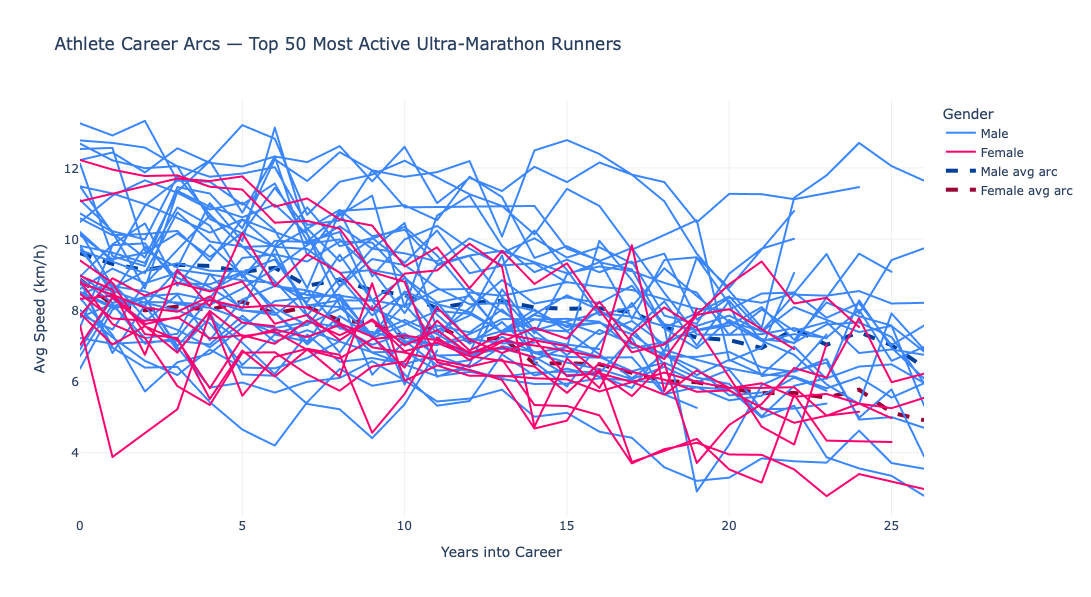

Saved viz6 PNG


In [4]:
athlete_counts = (
    df_clean.groupby('athlete_id')
    .agg(
        race_count=('year', 'count'),
        career_span=('year', lambda x: x.max() - x.min()),
        gender=('athlete_gender', 'first')
    ).reset_index()
)
active = athlete_counts[
    (athlete_counts['career_span'] >= 5) &
    (athlete_counts['race_count'] >= 10)
].nlargest(50, 'race_count')
print('Top athletes selected:', len(active))

top_ids = active['athlete_id'].tolist()
df_careers = df_clean[df_clean['athlete_id'].isin(top_ids)].copy()
career_yearly = (
    df_careers.groupby(['athlete_id', 'year'])
    .agg(
        avg_speed=('athlete_avg_speed', 'mean'),
        races=('athlete_avg_speed', 'count'),
        age=('athlete_age', 'mean'),
        gender=('athlete_gender', 'first')
    ).reset_index()
)
career_yearly['avg_speed'] = career_yearly['avg_speed'].round(2)
career_yearly['Gender'] = career_yearly['gender'].map({'M': 'Male', 'F': 'Female'})
career_yearly['first_year'] = career_yearly.groupby('athlete_id')['year'].transform('min')
career_yearly['career_year'] = career_yearly['year'] - career_yearly['first_year']

fig6 = px.line(
    career_yearly,
    x='career_year', y='avg_speed',
    color='Gender', line_group='athlete_id',
    color_discrete_map={'Male': '#3A86FF', 'Female': '#FF006E'},
    hover_data={'avg_speed': ':.2f', 'age': ':.0f', 'races': True, 'athlete_id': False},
    labels={
        'career_year': 'Years into Career',
        'avg_speed': 'Avg Speed (km/h)',
        'age': 'Age', 'races': 'Races that year'
    },
    title='Athlete Career Arcs — Top 50 Most Active Ultra-Marathon Runners'
)
mean_arc = career_yearly.groupby(['career_year','Gender']).agg(mean_speed=('avg_speed','mean')).reset_index()
for gender, color in [('Male','#003f99'),('Female','#990033')]:
    arc = mean_arc[mean_arc['Gender']==gender].sort_values('career_year')
    fig6.add_trace(go.Scatter(
        x=arc['career_year'], y=arc['mean_speed'],
        mode='lines', name=f'{gender} avg arc',
        line=dict(color=color, width=4, dash='dash')
    ))
fig6.update_layout(
    height=580, plot_bgcolor='white', paper_bgcolor='white',
    title_font_size=17,
    xaxis=dict(title='Years into Career', showgrid=True, gridcolor='#f0f0f0'),
    yaxis=dict(title='Avg Speed (km/h)', showgrid=True, gridcolor='#f0f0f0')
)
fig6.show()
fig6.write_image('../Viz/viz6_athlete_career_arc.png')
print('Saved viz6 PNG')